# Latent Structure Analysis of Breast Cancer Biomarkers Using Statistical Learning

## Overview
This project explores how statistical learning techniques such as clustering, principal component analysis (PCA), and matrix decomposition can reveal meaningful structure in breast cancer biomarker data.The goal is to investigate whether dimensionality reduction and unsupervised learning methods can support interpretable AI-assited approaches to cancer analysis.



In [15]:
# IMPORTS 
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from plotnine import *
import matplotlib.pyplot as plt

## Dataset

This project uses the Breast Cancer Wisconsin (Diagnostic) Dataset from the UCI Machine Learning Repository, accessed through scikit-learn.

The dataset contains numerical biomarker features computed from digitized images of breast mass cell nuclei obtained through fine needle aspiration (FNA). These features describe characteristics such as radius, texture, smoothness, compactness, and symmetry.

The dataset includes diagnosis labels indicating whether tumors are malignant or benign.

In [16]:
# Load Dataset 
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns = cancer.feature_names)

y = pd.Series(cancer.target)

## Exploratory Data Analysis 
In this section, we explore the structure of the breast cancer biomarker dataset.

Each row represents a tumor sample and each column represents a quantitative biomarker measurement extracted from digitized tumor images.

In [17]:
print(X.shape) #chart observations in format
X.head()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [18]:
X.describe() #statistic info

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Variance Analysis

Variance measures how spread out each biomarker is across tumor samples.


In [19]:
variances = X.var().sort_values(ascending=False)

print(variances)

worst area                 324167.385102
mean area                  123843.554318
area error                   2069.431583
worst perimeter              1129.130847
mean perimeter                590.440480
worst texture                  37.776483
worst radius                   23.360224
mean texture                   18.498909
mean radius                    12.418920
perimeter error                 4.087896
texture error                   0.304316
radius error                    0.076902
worst concavity                 0.043524
worst compactness               0.024755
mean concavity                  0.006355
worst concave points            0.004321
worst symmetry                  0.003828
mean compactness                0.002789
mean concave points             0.001506
concavity error                 0.000911
mean symmetry                   0.000752
worst smoothness                0.000521
worst fractal dimension         0.000326
compactness error               0.000321
mean smoothness 

### Interpretation
Biomarkers with higher variance show greater variability between tumors and may contain more distinguishing information.

Biomarkers with lower variance change less across samples and may contribute less information during clustering or dimensionality reduction.

## Correlation Structure

Correlation analysis helps identify relationships among biomarkers. 

Measures how strongly these variables move together, which is important for identifying the correlated variables, determining structural reduction in the PCA stage.

In [20]:
corr_matrix = X.corr()

corr_matrix.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316


## Interpretation

The correlation matrix helps identify relationships between biomarkers across tumor samples.

Strong positive correlations suggest that certain biomarkers tend to increase together, which may indicate related biological behavior or redundancy between features.

Strong negative correlations indicate that some biomarkers move in opposite directions across samples.

Highly correlated biomarkers are important in dimensionality reduction because PCA attempts to compress redundant information into fewer principal components while preserving major sources of variance in the dataset.

## Heatmap

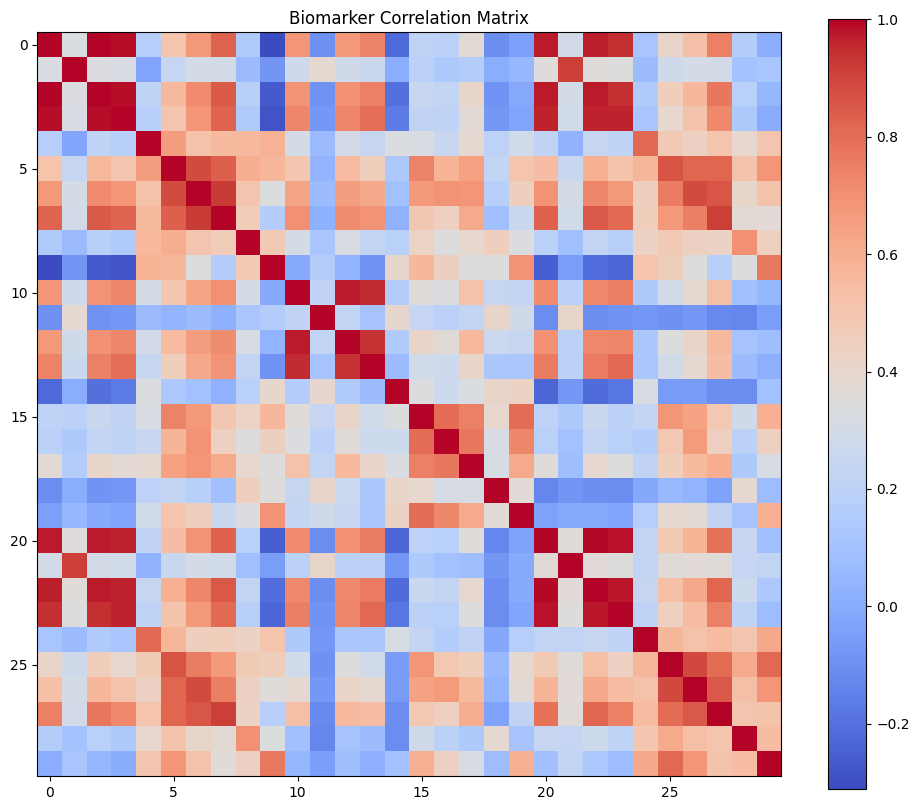

In [22]:
plt.figure(figsize=(12,10))
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()
plt.title("Biomarker Correlation Matrix")
plt.show()

## Interpretation

The biomarker correlation heatmap shows several strong positive correlations between groups of biomarkers, indicated by darker red regions.

These highly correlated regions suggest that certain biomarker measurements tend to increase together across tumor samples, which may reflect related biological characteristics of the tumors.

There are also some weak negative correlations, shown in blue, indicating that a small number of biomarkers move in opposite directions across samples.

The visible block-like patterns suggest redundancy within the dataset, meaning that some biomarkers contain overlapping information. This is important because dimensionality reduction methods such as PCA can compress correlated features into a smaller number of principal components while still preserving major sources of variation in the data.

Overall, the heatmap suggests that the dataset contains meaningful underlying structure rather than completely independent variables, making it well-suited for clustering and dimensionality reduction analysis.

## Data Standardization
Biomarkers exist on different numerical scales. Standardization ensures that no single biomarker dominates clustering or PCA calculations.

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## K-Means Model

In [24]:
kmeans = KMeans(n_clusters=2, random_state=0)

clusters = kmeans.fit_predict(X_scaled) 
print("Intertia:", kmeans.inertia_)
print("Cluster counts:", np.bincount(clusters))

Intertia: 11595.683312822128
Cluster counts: [381 188]


## Interpretation

The k-means clustering model produced an inertia value of approximately 11595.68. Inertia measures the total within-cluster variation, or how far observations are from their assigned cluster centroids. Lower inertia values indicate tighter and more internally similar clusters.

The model separated the dataset into two clusters containing 381 and 188 tumor samples respectively. The unequal cluster sizes suggest that the biomarker data is not evenly distributed across the two groups, which may reflect differences in the underlying biological structure of the tumor samples.

Since the original dataset contains malignant and benign tumor diagnoses, the clustering results may indicate that one tumor category is more common or exhibits greater variability than the other. However, because k-means is an unsupervised learning method, the clusters are formed solely based on biomarker similarity rather than the known diagnosis labels.

# Principal Component Analysis (PCA) 

PCA is a dimensionality reduction technique that transforms high-dimensional biomarker data into a smaller set of principal components while preserving major sources of variance.

This helps simplify complex datasets and reveal latent structure within tumor samples.

In [25]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [26]:
#how much variance/information each principal component preserves 
print(pca.explained_variance_ratio_)

[0.44272026 0.18971182]


## Interpretation

The explained variance ratio measures how much of the total variance in the biomarker dataset is captured by each principal component.

PC1 captures a substantially larger portion of the dataset’s variance than PC2, meaning that the first principal component preserves more of the original information and structure within the biomarker data.

This suggests that much of the variability across tumor samples can be summarized along the first principal component, while the second component captures additional but smaller sources of variation.

### PCA Dataframe

The PCA dataframe stores the low-dimensional representation of the tumor dataset after dimensionality reduction.

Instead of representing each tumor sample using all original biomarker features, each observation is now represented by its coordinates along the first two principal components (PC1 and PC2).

These coordinates describe the position of each tumor sample along the directions of greatest variance identified by PCA.

In [27]:
plot_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'Diagnosis': y
})

## PCA Visualization

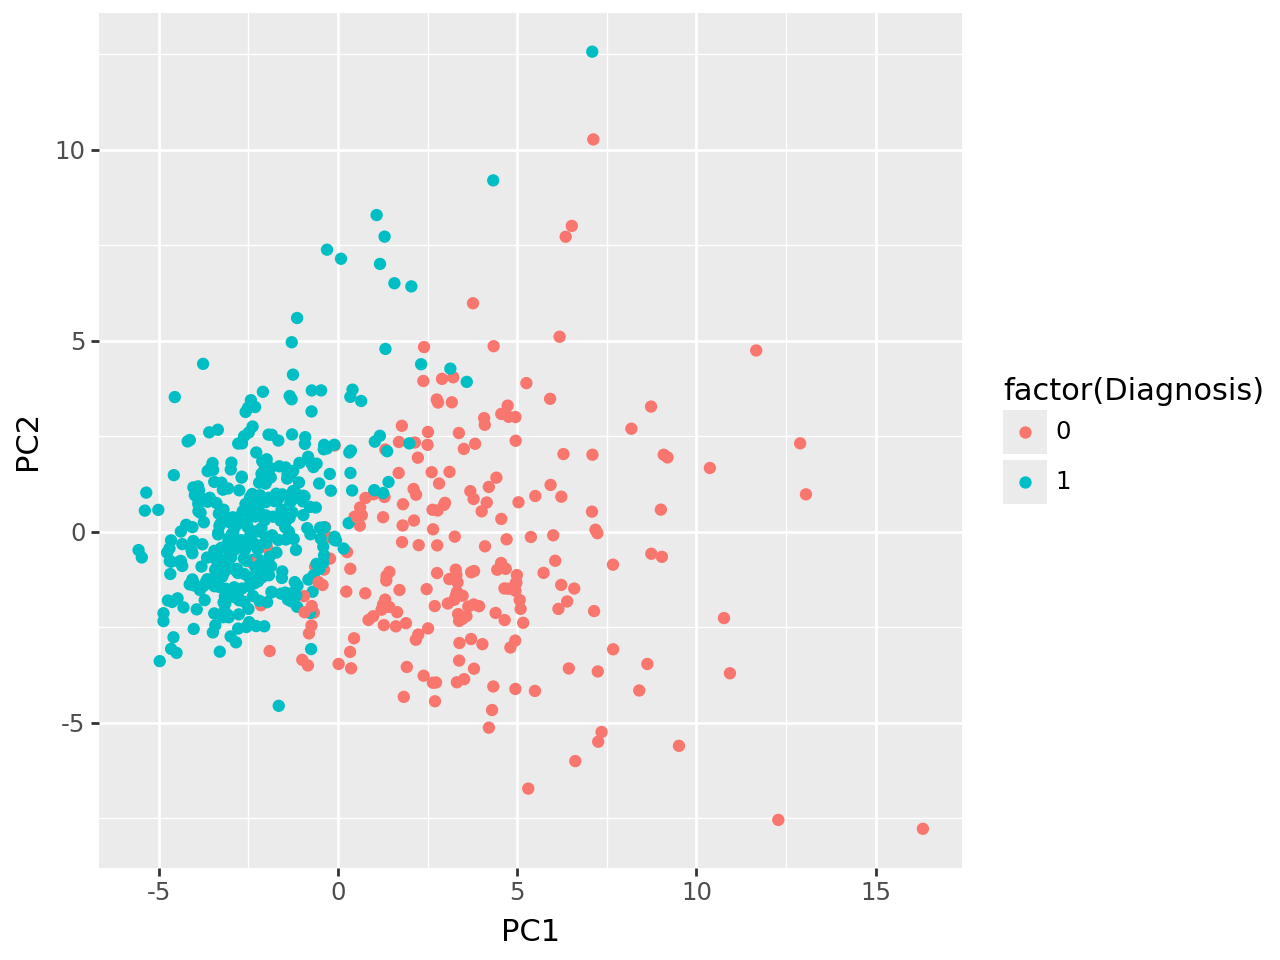

In [28]:
(
    ggplot(
        plot_df,
        aes(
            x='PC1',
            y='PC2',
            color='factor(Diagnosis)'
        )
    )
    + geom_point()
)

## Interpretation

The PCA visualization projects the high-dimensional biomarker dataset into two principal components while preserving major sources of variance.

The plot shows noticeable separation between the two diagnosis groups along the first principal component (PC1), suggesting that PC1 captures important biological variation related to tumor characteristics.

Tumor samples with diagnosis label 0 tend to appear farther along the positive PC1 direction, while diagnosis label 1 clusters more heavily along the negative PC1 region.

Although some overlap remains between the groups, this is expected in complex biological datasets where tumor characteristics are not perfectly separable.

Overall, the visualization suggests that PCA successfully compresses correlated biomarker information into a lower-dimensional representation while still preserving meaningful structure within the data.

## Singluar Value Decomposition (SVD) 

In [29]:
U, S, VT = np.linalg.svd(X_scaled)
print(S[:10])

[86.93235745 56.90677266 40.04263937 33.57058877 30.62887007 26.2104161
 19.60102663 16.46800391 15.4017255  14.12602481]


### Singular Value Interpretation

The singular values decrease steadily across components, indicating that the breast cancer biomarker dataset contains a smaller number of dominant underlying patterns that explain much of the variation in the data.

The first few singular values are substantially larger than the later values, suggesting that the strongest sources of variation are concentrated within a limited number of dimensions. This supports the use of dimensionality reduction techniques such as PCA, since much of the dataset’s important structure can be represented using fewer components.

The gradual decline in singular values also suggests that later components contribute less unique information and may represent smaller variations or redundancy among biomarkers.

## Singular Value Plot 

The plot graphs the ordered single values of a matrix in descending order, visualizing the significance of different components

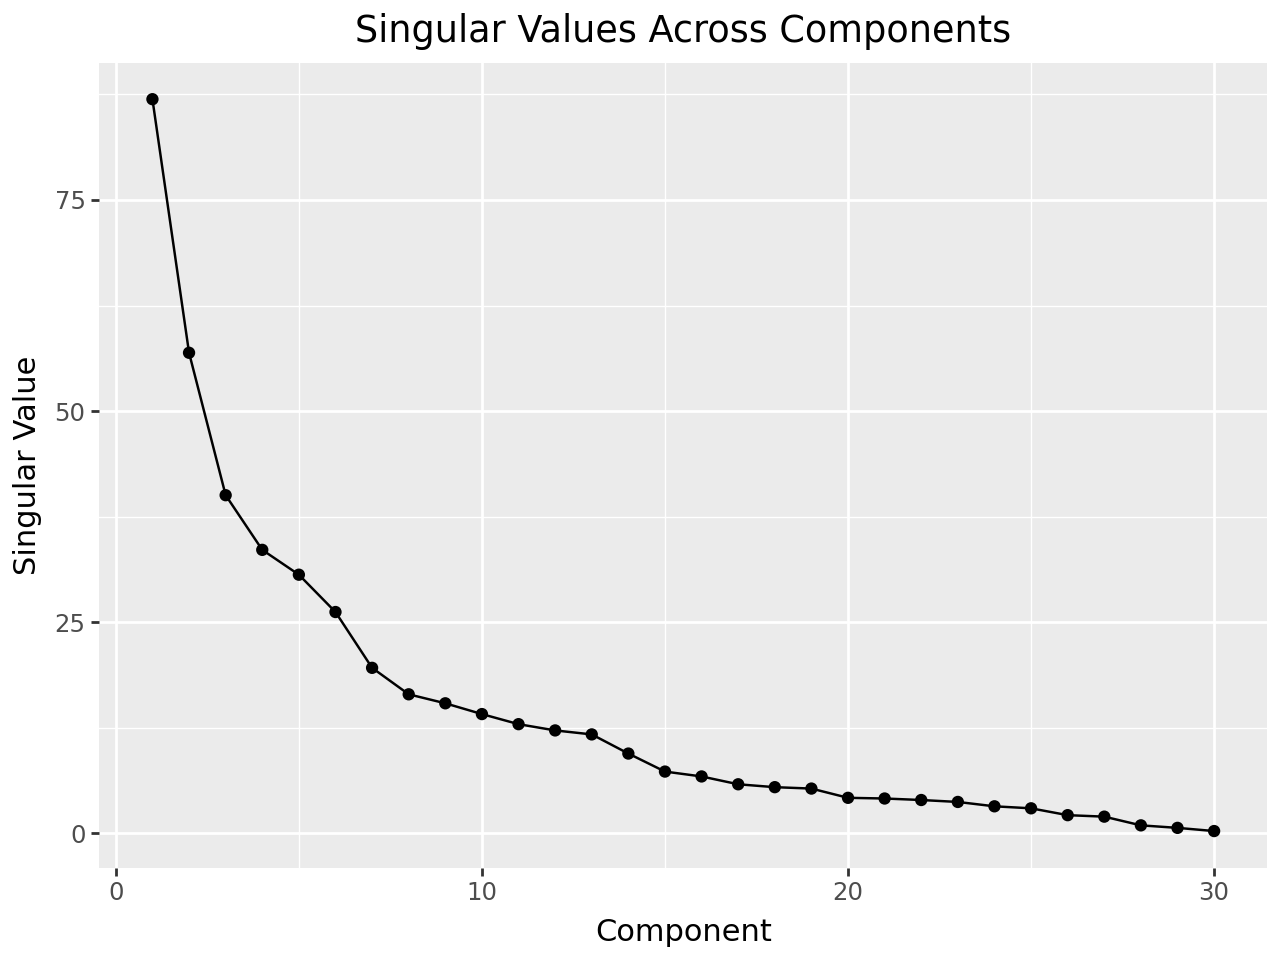

In [30]:
sv_df = pd.DataFrame({
    'Component': range(1, len(S)+1),
    'Singular Value': S
})

(
    ggplot(sv_df, aes(x='Component', y='Singular Value'))
    + geom_line()
    + geom_point()
    + labs(
        title='Singular Values Across Components',
        x='Component',
        y='Singular Value'
    )
)

### Singular Value Interpretation

The singular values decrease steadily across components, indicating that the breast cancer biomarker dataset contains a smaller number of dominant underlying patterns that explain much of the variation in the data.

The first few singular values are substantially larger than the later values, suggesting that the strongest sources of variation are concentrated within a limited number of dimensions. This supports the use of dimensionality reduction techniques such as PCA, since much of the dataset’s important structure can be represented using fewer components.

The gradual decline in singular values also suggests that later components contribute less unique information and may represent smaller variations or redundancy among biomarkers.

## Conclusion

This project explored the statistical structure of breast cancer biomarker data using clustering, Principal Component Analysis (PCA), and Singular Value Decomposition (SVD).

The analysis revealed that many tumor biomarkers exhibit strong correlations, suggesting overlapping biological behavior and redundancy within the dataset. PCA demonstrated that much of the variation across tumor samples could be preserved using a smaller number of principal components, allowing high-dimensional biomarker data to be represented in lower-dimensional space while still maintaining meaningful biological structure.

The PCA visualization showed noticeable separation between tumor diagnosis groups, suggesting that the biomarker measurements contain important latent patterns associated with tumor characteristics. Although some overlap remained between groups, the overall structure indicates that unsupervised statistical learning methods can capture biologically relevant variation within breast cancer data.

SVD further supported these findings by identifying dominant underlying patterns within the biomarker matrix. Larger singular values represented the strongest sources of variation, reinforcing the idea that a smaller number of latent structures explain much of the dataset’s complexity.

Overall, this project demonstrates how dimensionality reduction and statistical learning techniques can help simplify, visualize, and interpret complex biomedical datasets while preserving important information related to breast cancer tumor behavior.